# Geometric Basket Asian Pricing: Closed Form and Validation

This notebook focuses on the geometric basket Asian option under correlated Black-Scholes dynamics.

It contains the steps needed to:
1. simulate correlated risk-factor paths,
2. validate path generation with empirical metrics and diagnostic charts,
3. compute prices with the scalar and vectorized closed-form implementations,
4. validate discounted cash-flow consistency against the analytic time-zero price.

Import libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

from cashflows import basket_geom_asian_cashflows

from option_formulas import basket_geom_asian_vectorized

from IPython.display import clear_output

## Simulation of Paths

We set a multi-asset Black-Scholes model on a fixing grid $\{t_0,\dots,t_n\}$ and simulate paths in RNN layout `(simulations, time, assets)`.

Notation used below:
- $m$: number of assets,
- $n$: number of time steps,
- $S_{t_i}^j$: asset $j$ value at fixing time $t_i$,
- $\rho_{hk}$: instantaneous correlation between assets $h$ and $k$.

In [2]:
num_risk_factors = 3
initial_spot_values = [100.0, 95.0, 105.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.array([0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0])
num_sims = 30000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(num_sims=num_sims)

## Path Generation Diagnostics

### Plot simulation paths


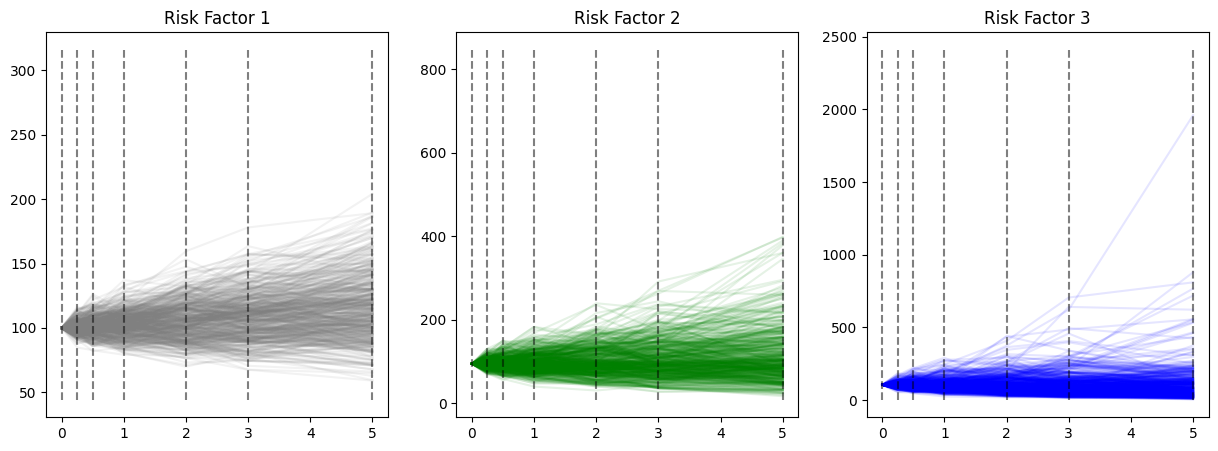

In [3]:
f, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].plot(time_steps, paths[0:500, :, 0].T, color = "grey", alpha = 0.1);
ax[0].set_title("Risk Factor 1");
ax[1].plot(time_steps, paths[0:500, :, 1].T
, color = "green", alpha = 0.1);
ax[1].set_title("Risk Factor 2");
ax[2].plot(time_steps, paths[0:500, :, 2].T
, color = "blue", alpha = 0.1);
ax[2].set_title("Risk Factor 3");   


ax[0].vlines(time_steps, np.min(paths.numpy()[:, :, 0]), np.max(paths.numpy()[:, :, 0]), color = "black", alpha = 0.5, linestyle = "--");
ax[1].vlines(time_steps, np.min(paths.numpy()[:, :, 1]), np.max(paths.numpy()[:, :, 1]), color = "black", alpha = 0.5, linestyle = "--");
ax[2].vlines(time_steps, np.min(paths.numpy()[:, :, 2]), np.max(paths.numpy()[:, :, 2]), color = "black", alpha = 0.5, linestyle = "--");


### Volatility and Correlation Test

The next cell uses an intentionally irregular grid to check that each increment has the configured instantaneous volatility and correlation structure after annualizing by the interval length.


In [4]:
return_paths = np.log(paths[:, 1:, :].numpy() / paths[:, :-1, :].numpy())

for i in range(len(time_steps)-1):

    vols = np.zeros(num_risk_factors)
    for j in range(num_risk_factors):
        vols[j] = np.std(return_paths[:, i, j]) / np.sqrt(time_steps[i+1] - time_steps[i])
    
    print(f"Volatilities at time step {i}: {vols}")
    print(f"Correlation matrix at time step {i}:")
    print(np.corrcoef(return_paths[:, i, :].T))
    print("\n")
    


Volatilities at time step 0: [0.09943904 0.24847551 0.39643417]
Correlation matrix at time step 0:
[[ 1.          0.80117854  0.09949863]
 [ 0.80117854  1.         -0.49864226]
 [ 0.09949863 -0.49864226  1.        ]]


Volatilities at time step 1: [0.09931367 0.24938413 0.39862333]
Correlation matrix at time step 1:
[[ 1.          0.79988218  0.09392238]
 [ 0.79988218  1.         -0.50532824]
 [ 0.09392238 -0.50532824  1.        ]]


Volatilities at time step 2: [0.10080181 0.25124928 0.40196282]
Correlation matrix at time step 2:
[[ 1.          0.80080524  0.10345654]
 [ 0.80080524  1.         -0.49589572]
 [ 0.10345654 -0.49589572  1.        ]]


Volatilities at time step 3: [0.09967163 0.24966629 0.40065586]
Correlation matrix at time step 3:
[[ 1.          0.79865489  0.09829374]
 [ 0.79865489  1.         -0.50341519]
 [ 0.09829374 -0.50341519  1.        ]]


Volatilities at time step 4: [0.09951592 0.24809367 0.39847923]
Correlation matrix at time step 4:
[[ 1.          0.79921483

### Brownian Bridge simulation

In [5]:
paths_bridge = simulator.simulate_paths_with_bridge(30000, 4, [100,90,80])

### Plot simulation paths

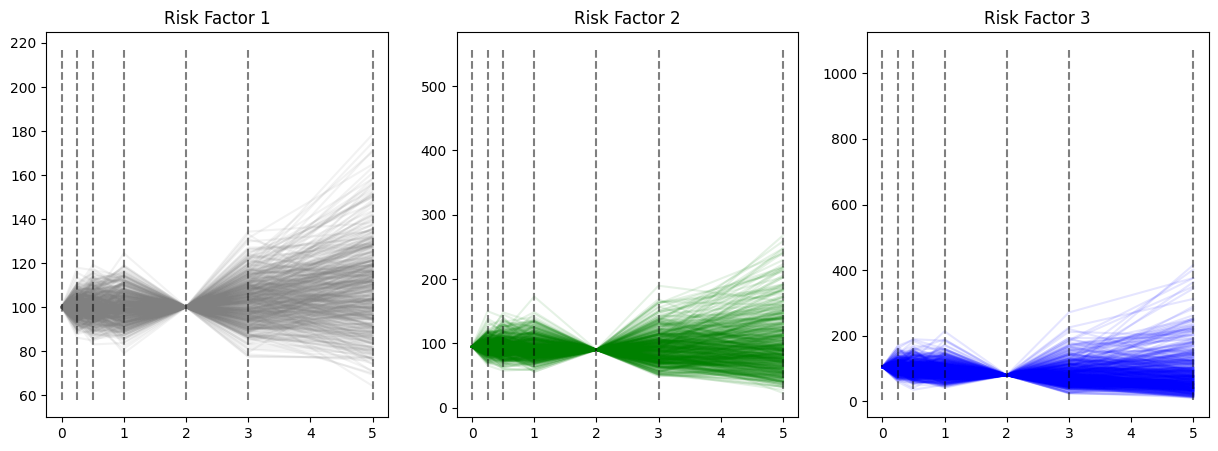

In [6]:
f, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].plot(time_steps, paths_bridge[0:500, :, 0].T, color = "grey", alpha = 0.1);
ax[0].set_title("Risk Factor 1");
ax[1].plot(time_steps, paths_bridge[0:500, :, 1].T
, color = "green", alpha = 0.1);
ax[1].set_title("Risk Factor 2");
ax[2].plot(time_steps, paths_bridge[0:500, :, 2].T
, color = "blue", alpha = 0.1);
ax[2].set_title("Risk Factor 3");   


ax[0].vlines(time_steps, np.min(paths_bridge.numpy()[:, :, 0]), np.max(paths_bridge.numpy()[:, :, 0]), color = "black", alpha = 0.5, linestyle = "--");
ax[1].vlines(time_steps, np.min(paths_bridge.numpy()[:, :, 1]), np.max(paths_bridge.numpy()[:, :, 1]), color = "black", alpha = 0.5, linestyle = "--");
ax[2].vlines(time_steps, np.min(paths_bridge.numpy()[:, :, 2]), np.max(paths_bridge.numpy()[:, :, 2]), color = "black", alpha = 0.5, linestyle = "--");

### Correlation Test

The next cell uses an intentionally irregular grid to check that each increment has the configured instantaneous volatility and correlation structure after annualizing by the interval length.

In [7]:
return_paths = np.log(paths_bridge[:, 1:, :].numpy() / paths_bridge[:, :-1, :].numpy())

for i in range(len(time_steps)-1):

    print(f"Correlation matrix at time step {i}:")
    print(np.corrcoef(return_paths[:, i, :].T))
    print("\n")

    

Correlation matrix at time step 0:
[[ 1.          0.80239173  0.09197238]
 [ 0.80239173  1.         -0.50351167]
 [ 0.09197238 -0.50351167  1.        ]]


Correlation matrix at time step 1:
[[ 1.          0.80129119  0.0930744 ]
 [ 0.80129119  1.         -0.50384957]
 [ 0.0930744  -0.50384957  1.        ]]


Correlation matrix at time step 2:
[[ 1.          0.80097519  0.09557075]
 [ 0.80097519  1.         -0.50260161]
 [ 0.09557075 -0.50260161  1.        ]]


Correlation matrix at time step 3:
[[ 1.          0.80022515  0.0961274 ]
 [ 0.80022515  1.         -0.5032897 ]
 [ 0.0961274  -0.5032897   1.        ]]


Correlation matrix at time step 4:
[[ 1.          0.80043972  0.1020353 ]
 [ 0.80043972  1.         -0.49759189]
 [ 0.1020353  -0.49759189  1.        ]]


Correlation matrix at time step 5:
[[ 1.          0.79952819  0.09074488]
 [ 0.79952819  1.         -0.50885795]
 [ 0.09074488 -0.50885795  1.        ]]




## Closed form formula tests

### Closed-Form Derivation

We price

$$V_T = \left(\left(\prod_{i=1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+.$$

At date $t_v$:

$$V_{t_v}=E\left[\left(\left(\prod_{i=1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+e^{-r(t_n-t_v)}\Big|\mathcal{F}_{t_v}\right].$$

Split known and future fixings:

$$V_{t_v}=E\left[\left(\left(\prod_{i=1}^{v}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}\left(\prod_{i=v+1}^{n}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}-1\right)^+e^{-r(t_n-t_v)}\Big|\mathcal{F}_{t_v}\right].$$

Under correlated Black-Scholes,

$$r^j_{t_v,t_i}=\left(r-\frac{\sigma_j^2}{2}\right)(t_i-t_v)+\sigma_j\left(W_{t_i}^j-W_{t_v}^j\right),$$

and

$$\exp\left(\frac{1}{nm}\sum_{i=v+1}^{n}\sum_{j=1}^{m}r^j_{t_v,t_i}\right)\stackrel{d}{=}\exp\left(\mu+\sqrt{V}\phi\right),\quad \phi\sim N(0,1).$$

with

$$\mu=\frac{1}{nm}\sum_{i=v+1}^{n}\sum_{j=1}^{m}\left(r-\frac{\sigma_j^2}{2}\right)(t_i-t_v),$$

$$V=\frac{1}{n^2m^2}\sum_{h=1}^{m}\sum_{k=1}^{m}\sum_{i=v+1}^{n}\sum_{j=v+1}^{n}\sigma_h\sigma_k\rho_{hk}(\min(t_i,t_j)-t_v).$$

So the value is Black with strike $K=1$, maturity $T=t_n-t_v$, volatility $\hat\sigma=\sqrt{V/(t_n-t_v)}$, and forward

$$F=\left(\prod_{i=1}^{v}\prod_{j=1}^{m}\frac{S_{t_i}^j}{S_{t_0}^j}\right)^{\frac{1}{nm}}\left(\prod_{j=1}^{m}\left(\frac{S_{t_v}^j}{S_{t_0}^j}\right)^{n-v}\right)^{\frac{1}{nm}}\exp\left(\mu+\frac{V}{2}\right).$$

### PFEs of closed form formula

In [12]:

num_risk_factors = 3
initial_spot_values = [100.0, 95.0, 105.0]
risk_free_rate = 0.03
drift_array = [risk_free_rate, risk_free_rate, risk_free_rate]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0.0, 5.0, 61)
num_sims = 30000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)


paths_risk_factors = simulator.simulate_paths(num_sims=num_sims)

results = basket_geom_asian_cashflows(time_steps, risk_free_rate, 3, paths_risk_factors, 
                                      True, 1.0, "cpu", torch.float64, False)

np.mean(results["discounted_cashflows"][:, 0].numpy())

option_price = basket_geom_asian_vectorized(time_steps, risk_free_rate, 3, volatility_array, correl_matrix,  
                                            paths_risk_factors, True, "cpu", torch.float64, False)


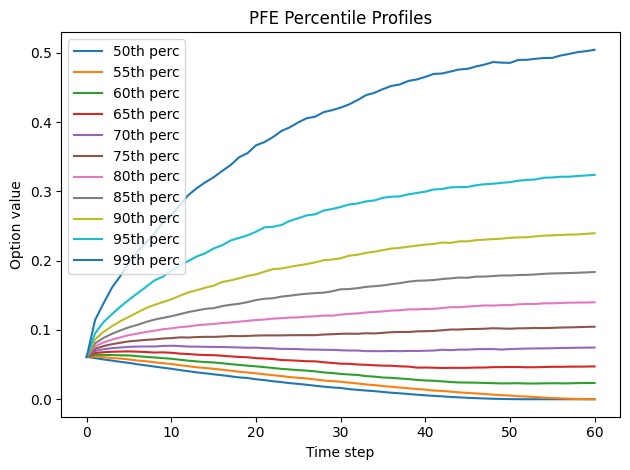

In [13]:
percentiles = [50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 99]
option_price_np = option_price.numpy()

for q in percentiles:
    pfe_q = np.percentile(option_price_np, axis=0, q=q)
    plt.plot(pfe_q, label=f"{q}th perc")

plt.legend()
plt.title("PFE Percentile Profiles")
plt.xlabel("Time step")
plt.ylabel("Option value")
plt.tight_layout()

### Test closed form formula vs discounted cash flows

In [38]:

seed = np.random.randint(0, 2**32, dtype=np.uint32)



num_risk_factors = 3
initial_spot_values = [100.0, 95.0, 105.0]
risk_free_rate = 0.03
drift_array = [risk_free_rate, risk_free_rate, risk_free_rate]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0.0, 5.0, 61)
num_sims = 5000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

option_price_array = np.zeros(len(time_steps))
average_disc_cf_array = np.zeros(len(time_steps))
average_disc_std_array = np.zeros(len(time_steps))

for i in range(len(time_steps)):
    print(i)

    torch.manual_seed(seed)

    risk_factor_paths = simulator.simulate_same_path_up_do_date(num_sims=num_sims, pivot_step_idx=i)

    results = basket_geom_asian_cashflows(time_steps, risk_free_rate, 3, risk_factor_paths, 
                                      True, 1.0, "cpu", torch.float64, False)

    option_price = basket_geom_asian_vectorized(time_steps, risk_free_rate, 3, volatility_array, correl_matrix,  
                                            risk_factor_paths, True, "cpu", torch.float64, False)

    option_price_array[i] = option_price[:,i].mean().item()
    average_disc_cf_array[i] = results["discounted_cashflows"][:,i].mean().item()
    average_disc_std_array[i] = results["discounted_cashflows"][:,i].std().item()

    '''
    f, ax = plt.subplots(1,3, figsize=(15,5))

    ax[0].plot(time_steps, risk_factor_paths[0:500, :, 0].T, color = "grey", alpha = 0.1);
    ax[0].set_title("Risk Factor 1");
    ax[1].plot(time_steps, risk_factor_paths[0:500, :, 1].T
    , color = "green", alpha = 0.1);
    ax[1].set_title("Risk Factor 2");
    ax[2].plot(time_steps, risk_factor_paths[0:500, :, 2].T
    , color = "blue", alpha = 0.1);
    ax[2].set_title("Risk Factor 3");   

    plt.show()

    
    '''

    clear_output(wait=True)




60


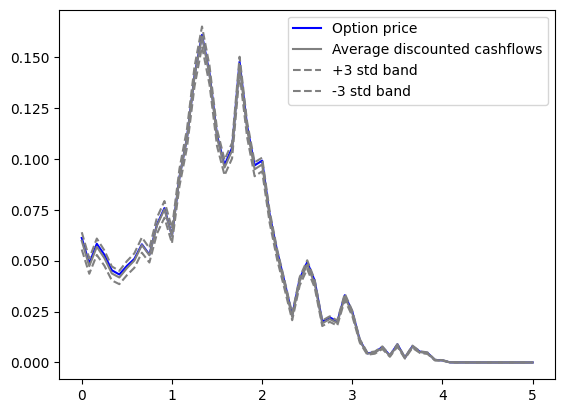

In [40]:
plt.plot(time_steps, option_price_array, label="Option price", color="blue")
plt.plot(time_steps, average_disc_cf_array, color="grey", label="Average discounted cashflows")
plt.plot(time_steps, average_disc_cf_array + 3 * average_disc_std_array / np.sqrt(num_sims), color="grey", linestyle="--", label="+3 std band")
plt.plot(time_steps, average_disc_cf_array - 3 * average_disc_std_array / np.sqrt(num_sims), color="grey", linestyle="--", label="-3 std band")
plt.legend()
plt.show()